## Submission 3. Phase of long theta and remote content
#### With theta from Corpus Callosum electrodes
Change%20of%20Mind%20Analysis/figure_single_cell/MakeTheta.ipynb

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure4d import (time_to_phase,
    remote_phase_by_bin, distance_phase_by_bin)
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta, MUATheta
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.changeOfMind import color_by_rat
from spyglass.shijiegu.theta_mua import load_theta_from_calculations

[2026-04-27 14:23:52,640][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[14:24:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:24:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:24:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:24:07][WARNING] Spyglass: Deprecation: this class has b

In [3]:
from spyglass.shijiegu.Analysis_SGU import MUAThetaNWB, AnalysisNwbfile
import pynwb

In [4]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']


animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']


animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']

bad_sessions = [] # these sessions have incomplete number of sorted tetrodes

In [5]:
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="theta_phase")

[14:26:24][INFO] Spyglass: Starting {'export_id': 105}
INFO:spyglass:Starting {'export_id': 105}


In [10]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'

data_type = "mua"#"corpus_callosum"
decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False

for animal in list_of_days_animals.keys():
    phase_all = [] #remote theta event
    p_local_all = []
    sessions = []
    
    for d in list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            phase, p_local = remote_phase_by_bin(nwb_copy_file_name, session_name,
                                                  decode_name_remote, minimum_duration_remote, proportion = proportion,
                                                  min_posterior = min_posterior, 
                                                  use_spyglass = False,
                                                  long_flag = False, data_type = data_type)
            phase_all += phase
            p_local_all += p_local
            
            sessions.append((animal,d, session_name))
            

    # save data
    data = {"phase_all": phase_all, "p_local_all": p_local_all,
            "sessions": sessions
           }
    data_filename = f"remote_content_{animal}_phase_version2_{data_type}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")
    

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240105_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240105_ 2         02_Rev2Session pos 1 valid ti
lewis20240105_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240105_ 4         04_Rev2Session pos 3 valid ti
lewis20240105_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240105_ 6         06_Rev2Session pos 5 valid ti
lewis20240105_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240105_ 8         08_Rev2Session pos 7 valid ti
lewis20240105_ 9         09_Rev2Sleep5  pos 8 valid ti
lewis20240105_ 10        10_Rev2Session pos 9 valid ti
 (Total: 10)

arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 7
arm_track_segment 7
arm_track_segment 7
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 7
arm_track_segment 6
arm_track_segment 6
arm_tr

### local theta

In [ ]:
#ChangeofMindTheta()

In [ ]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'

decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
data_type = "mua"#"corpus_callosum"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False

for animal in ["molly","eliot","klein","julio","lewis"]:#["molly","julio","lewis","klein","eliot"]:
    phase_all = [] #remote theta event
    p_local_all = []
    sessions = []
    
    for d in list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            phase, p_local = distance_phase_by_bin(
                nwb_copy_file_name, session_name, decode_name_long, minimum_duration_long,
                 proportion = 0.1,
                 use_spyglass = False,
                 sd = sd, hpd = hpd,
                 data_type = data_type)
            phase_all += phase
            p_local_all += p_local
            
            sessions.append((animal,d, session_name))
            

    # save data
    data = {"phase_all": phase_all, "distance_all": p_local_all,
            "sessions": sessions
           }
    data_filename = f"local_content_{animal}_phase_version2_{data_type}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220416_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220416_ 2         02_Seq2Session pos 1 valid ti
molly20220416_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220416_ 4         04_Seq2Session pos 3 valid ti
molly20220416_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220416_ 6         06_Seq2Session pos 5 valid ti
molly20220416_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220416_ 8         08_Seq2Session pos 7 valid ti
molly20220416_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220416_ 10        10_Seq2Session pos 9 valid ti
molly20220416_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220417_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220417_ 2         02_Seq2Session pos 1 valid ti
molly20220417_ 3         03_Seq2Sleep2  pos 2 valid

In [14]:
ExportSelection().stop_export(**paper_key, analysis_id="theta_phase")

[19:39:33][WARNING] Spyglass: Export not in progress.


### Plotting

In [12]:
def return_plotting_quantities(animal, data_type, bins = None):
    #animal = 'eliot'
    #data_type = "corpus_callosum"

    if bins is None:
        bins = np.linspace(0, 2*np.pi, 14)
        
    """remote content"""
    data_filename = f"remote_content_{animal}_phase_version2_{data_type}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")
    
    sessions = data["sessions"]
    
    phase_all = data["phase_all"]
    p_local_all = np.array(data["p_local_all"])
    
    bin_ind = np.digitize(phase_all, bins)
    mean_remote = np.array([np.nanmean(p_local_all[bin_ind == ind]) for ind in range(1,len(bins))])
    mean_remote = 1 - mean_remote
    # mean_remote = np.array([np.nanmean(np.log((1-p_local_all[bin_ind == ind])/(p_local_all[bin_ind == ind]))) for ind in range(1,len(bins))])
    # sd_remote = np.array([np.nanstd(
    #    np.log((1-p_local_all[bin_ind == ind])/(p_local_all[bin_ind == ind]))
    # ) for ind in range(1,len(bins))])
    
    #mean_remote = 1 - mean_plocal
    sd_remote = np.array([np.nanstd(1-p_local_all[bin_ind == ind]) for ind in range(1,len(bins))])
    N = np.array([np.sum(bin_ind == ind) for ind in range(1,len(bins))])
    sd_remote = sd_remote / np.sqrt(N)
    
    """local content"""
    data_filename = f"local_content_{animal}_phase_version2_{data_type}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")
    
    sessions = data["sessions"]
    
    phase_all = data["phase_all"]
    distance_all = np.array(data["distance_all"])
    
    bin_ind = np.digitize(phase_all, bins)
    mean_dist = np.array([np.nanmedian(distance_all[bin_ind == ind]) for ind in range(1,len(bins))])
    sd_distance = np.array([np.nanstd(distance_all[bin_ind == ind]) for ind in range(1,len(bins))])
    N = np.array([np.sum(bin_ind == ind) for ind in range(1,len(bins))])
    sd_distance = sd_distance / np.sqrt(N)

    return mean_remote,sd_remote, mean_dist, sd_distance


In [13]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}


In [299]:
def duplicate(x):
    return np.concatenate((x,x))
def duplicate_x(x):
    return np.concatenate((x,x+np.pi*2))

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/remote_content_molly_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/local_content_molly_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/remote_content_eliot_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/local_content_eliot_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/remote_content_julio_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/local_content_julio_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/remote_content_klein_phase_version2_mua.pkl
Data loaded from /home/shijiegu/Documents/sp

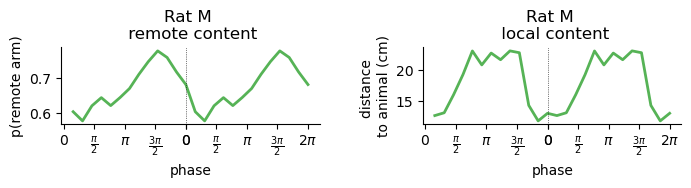

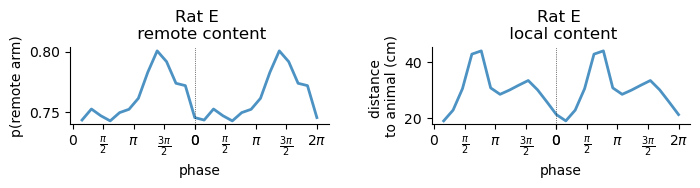

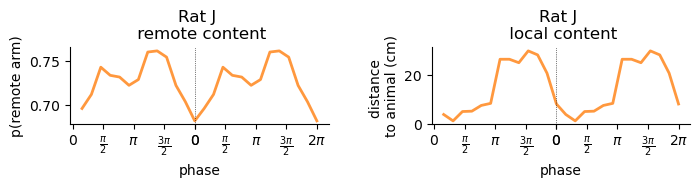

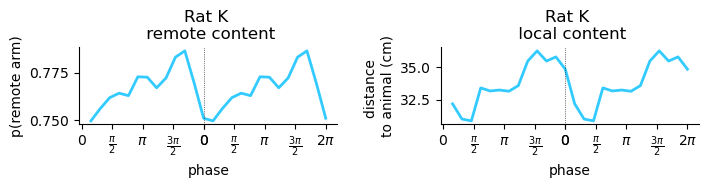

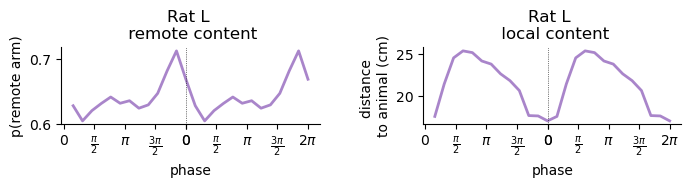

In [316]:
data_type = "mua"
bins = np.linspace(0, 2*np.pi, 14)

ind = 0
x = bins[1:]
y = mean_remote
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    fig, axes = plt.subplots(1, 2, figsize = (8,1))

    (mean_remote,sd_remote,
     mean_dist, sd_distance) = return_plotting_quantities(
         animal, data_type, bins)

    X = duplicate_x(x)
    y = mean_remote #np.log(mean_remote/(1-mean_remote))
    Y = duplicate(y) #- np.mean(y)
    #Y_err = 10*duplicate(sd_remote)
    axes[0].plot(X, Y, color = color_by_rat[animal], linewidth = 2, alpha = 0.8)
    #axes[0].fill_between(X, Y - Y_err, Y + Y_err,
    #                 alpha = 0.3, color = color_by_rat[animal])

    Y = duplicate(mean_dist)#(duplicate(mean_dist) - np.mean(mean_dist))/np.std(mean_dist)
    Y_err = duplicate(sd_distance)
    axes[1].plot(X, Y, color = color_by_rat[animal], linewidth = 2, alpha = 0.8)
    #axes[1].fill_between(X, Y - Y_err, Y + Y_err,
    #                     alpha = 0.5, color = color_by_rat[animal])

    axes[0].axvline(2*np.pi, linewidth = 0.5, linestyle = ':', color = 'k')
    axes[1].axvline(2*np.pi, linewidth = 0.5, linestyle = ':', color = 'k')

    axes[0].set_xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi,
     0 + np.pi * 2, np.pi/2 + np.pi * 2, np.pi + np.pi * 2, 3*np.pi/2 + np.pi * 2, 2*np.pi + np.pi * 2],
    [r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$',
    r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])

    axes[1].set_xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi,
     0 + np.pi * 2, np.pi/2 + np.pi * 2, np.pi + np.pi * 2, 3*np.pi/2 + np.pi * 2, 2*np.pi + np.pi * 2],
    [r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$',
    r'$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])
    
    
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    axes[0].set_xlabel("phase")
    axes[1].set_xlabel("phase")
    
    axes[0].set_ylabel("p(remote arm)")
    axes[1].set_ylabel("distance \nto animal (cm)")
    axes[0].set_title(f"Rat {animal[0].upper()} \n remote content")
    axes[1].set_title(f"Rat {animal[0].upper()} \n local content")
    ind += 1
    
    fig.subplots_adjust(wspace=0.4)

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/content_phase_{animal}"
    plt.savefig(file_path + ".pdf",bbox_inches='tight')
    plt.savefig(file_path + ".png") 

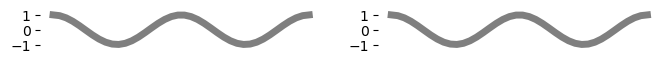

In [303]:
fig, axes = plt.subplots(1, 2, figsize = (8,0.5))
X = np.linspace(0, 4*np.pi, 40)
A = 1
axes[0].plot(X, np.cos(X) * A, linewidth = 5, alpha = 0.5, color = 'k')
axes[1].plot(X, np.cos(X) * A, linewidth = 5, alpha = 0.5, color = 'k')

for ind in [0,1]:
    axes[ind].spines['top'].set_visible(False)
    axes[ind].spines['right'].set_visible(False)
    axes[ind].spines['bottom'].set_visible(False)
    axes[ind].spines['left'].set_visible(False)
    axes[ind].set_xticks([])
    axes[ind].set_ylim([-1.3*A, 1.3*A])

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/content_phase_theta"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png") 

In [54]:
bins

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5])

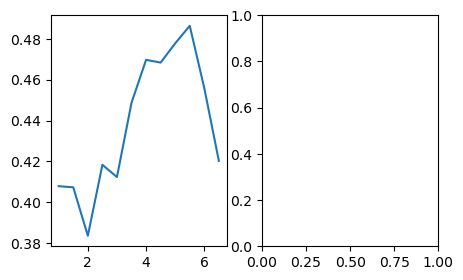

In [75]:
fig, axes = plt.subplots(1, 2, figsize = (5,3))
axes[0].plot(bins[1:], mean_remote)


### Phase histogram

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/content_lewis_theta_phase.pkl


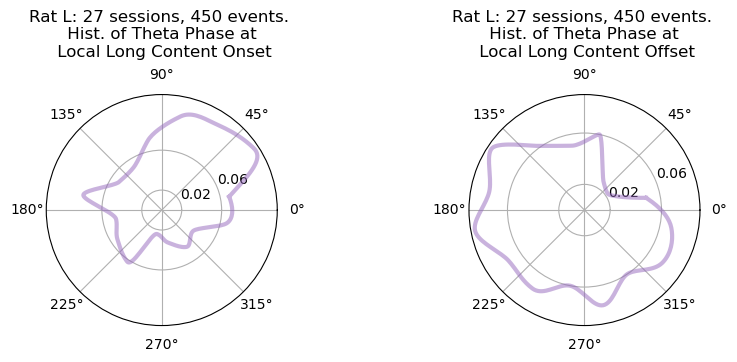

In [120]:
animal = 'lewis'

data_filename = f"content_{animal}_theta_phase.pkl"
output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    data = pickle.load(file)
print(f"Data loaded from {output_path}")

sessions = data["sessions"]

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["l_phase_start_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Local Long Content Onset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06])

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["l_phase_end_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Local Long Content Offset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06])

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/longlocal_content_phase_{animal}_muatheta.pdf',dpi=300,bbox_inches='tight')

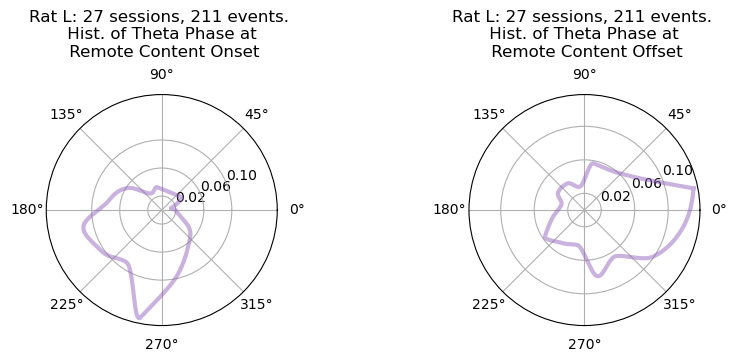

In [121]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))
sessions = data["sessions"]

#### 1. Onset
ax = axes[0]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["r_phase_start_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Onset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06, 0.1])

#### 2. Offset
ax = axes[1]
#angles = np.random.uniform(0, 2 * np.pi, 1000)
angles = data["r_phase_end_all"]
plot_polar_hist(angles, ax, animal, num_bins = 10)

# 5. Customize the plot (optional)
ax.set_title(f'Rat {animal[0].upper()}: {len(sessions)} sessions, {len(angles)} events. \n Hist. of Theta Phase at \n Remote Content Offset', va='bottom')
ax.grid(True)
ax.set_yticks([0.02, 0.06, 0.1])

# You can further customize labels, tick marks, etc.

# 6. Display the plot
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/remote_content_phase_{animal}_muatheta.pdf',dpi=300,bbox_inches='tight')


### End here